Text(0.5, 1.0, 'Original Spectrum, scaled')

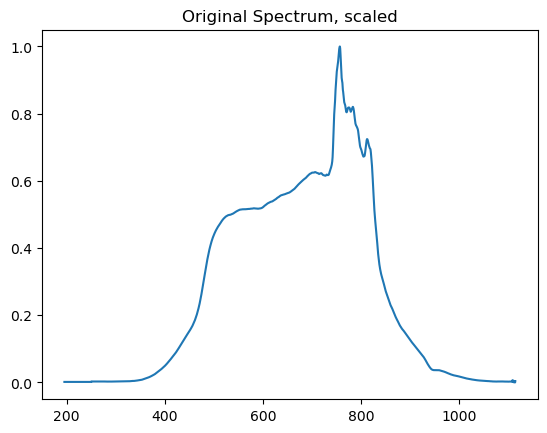

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import ifft, fftshift, fftfreq
from scipy.interpolate import interp1d
from sklearn.preprocessing import MinMaxScaler

# ---------------------------
# 1. Load spectrum from CSV
# ---------------------------
# Replace with your actual file path
file_path = 'mean_fs_spectrum.csv' 
df = pd.read_csv(file_path)
df.columns = ['Wavelength(nm)', 'Intensity']

# Normalize intensity between 0 and 1
x_nm = df['Wavelength(nm)'].values
y = df['Intensity'].values
y = MinMaxScaler().fit_transform(y.reshape(-1, 1)).flatten()

plt.plot(x_nm,y)
plt.title("Original Spectrum, scaled")

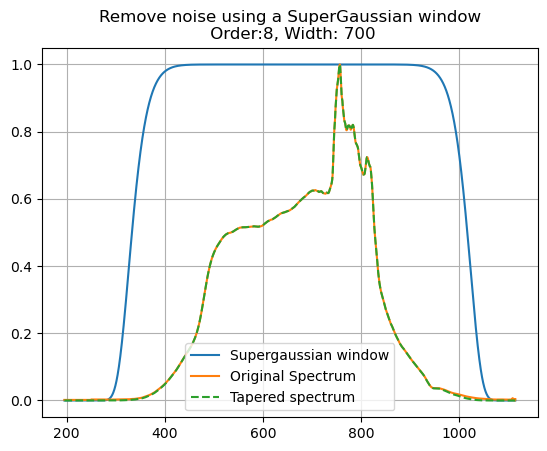

In [36]:
# ---------------------------
# 2. Apply Super-Gaussian Taper
# ---------------------------
from cProfile import label

from matplotlib.lines import lineStyles

def supergaussian(x, center, width, order, amplitude=1):
    return amplitude * np.exp(-((x - center) / (width / 2)) ** (2 * order))


center=675
width=700
order=8 # definition of the supergaussian

supergauss = supergaussian(x_nm, center, width, order)
tapered = y * supergauss

plt.plot(x_nm, supergauss, label="Supergaussian window")
plt.plot(x_nm, y, label="Original Spectrum")
plt.plot(x_nm, tapered, label = "Tapered spectrum", linestyle="--")
plt.grid(1)
plt.title(f"Remove noise using a SuperGaussian window\n Order:{order}, Width: {width}")
plt.legend()

<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_7013/3316176365.py:18: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("$\omega$ - rad/fs")
/tmp/ipykernel_7013/3316176365.py:20: SyntaxWarning: invalid escape sequence '\o'
  plt.title(f"Conversion of x-axis to $\omega$-domain")
/home/soumyajeet/miniconda3/envs/computational/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/soumyajeet/miniconda3/envs/computational/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Conversion of x-axis to $\\omega$-domain')

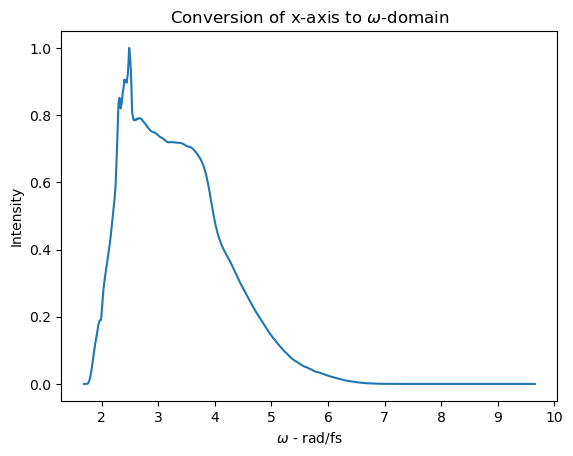

In [37]:
# ---------------------------
# 3. Convert to Angular Frequency
# ---------------------------
c_nm_fs = 299792458 * 1e-6  # speed of light in nm/fs
omega = 2 * np.pi * c_nm_fs / x_nm  # angular frequency in rad/fs

# Sort spectrum for FFT compatibility
sorted_idx = np.argsort(omega)
omega_sorted = omega[sorted_idx]
tapered_sorted = tapered[sorted_idx]

# Interpret tapered spectrum as E(ω) (field, not intensity)
# spectrum is intensity, convert to field amplitude
E_omega_pos = np.sqrt(tapered_sorted).astype(np.complex128)


plt.plot(omega_sorted, E_omega_pos)
plt.xlabel("$\omega$ - rad/fs")
plt.ylabel("Intensity")
plt.title(f"Conversion of x-axis to $\omega$-domain")

In [38]:
# ---------------------------
# 4. Construct Hermitian-Symmetric Spectrum
# # ---------------------------

# Zero-pad in frequency domain instead of interpolation
padding_factor = 10  # e.g., 10x zero-padding
n_pad = len(E_omega_pos) * (padding_factor - 1) // 2 # divides into 4x on +x and 4x on -x

# Pad with zeros on both sides
E_omega_padded = np.concatenate([
    np.zeros(n_pad, dtype=complex),
    E_omega_pos,
    np.zeros(n_pad, dtype=complex)
]) # adding zeros to the y-axis values, empty 4x bins on each side 

# this the main hermition symmetry creation
E_omega_full = np.concatenate([E_omega_padded, np.conj(E_omega_padded[::-1])])

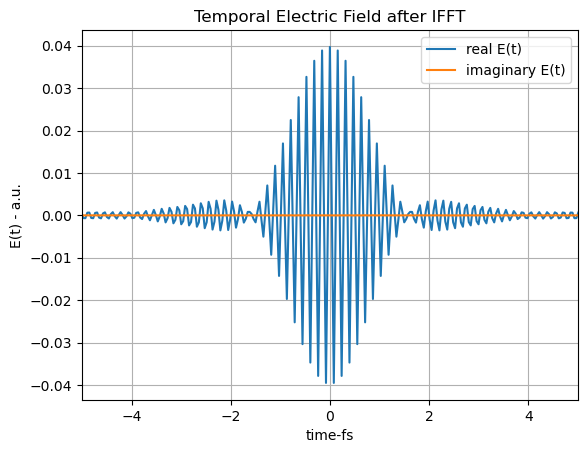

/tmp/ipykernel_7013/632601810.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


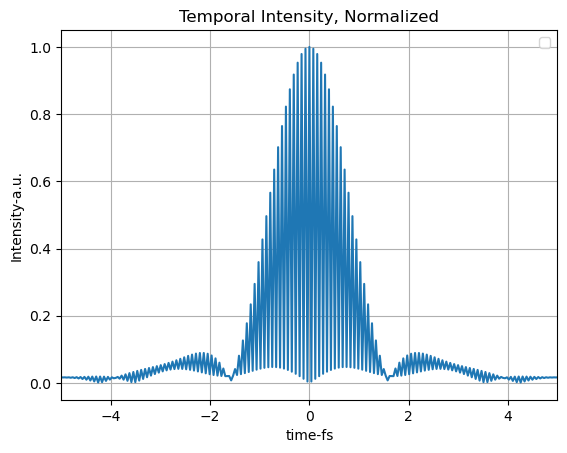

In [39]:
# ---------------------------
# 5. Implementing the actual IFFT
# # ---------------------------

# creating the time axis of the IFFT
n = len(E_omega_full) # number of time bins same as frequency bins
domega = np.mean(np.diff(omega_sorted)) # takes the mean del-omega to create del-t
t_fs = fftshift(fftfreq(n, domega / (2 * np.pi)))

# calculating the IFFT on the padded E(omega)
E_t = fftshift(ifft(E_omega_full))
I_t = np.abs(E_t)
I_t /= np.max(I_t)  # normalize intensity

plt.plot(t_fs, np.real(E_t), label= "real E(t)")
plt.plot(t_fs, np.imag(E_t), label="imaginary E(t)")
plt.grid(1)
plt.title(f"Temporal Electric Field after IFFT")
plt.legend()
plt.xlabel("time-fs")
plt.ylabel("E(t) - a.u.")
plt.xlim(-5, 5)
plt.show()


plt.plot(t_fs, I_t)
plt.grid(1)
plt.title(f"Temporal Intensity, Normalized")
plt.legend()
plt.xlabel("time-fs")
plt.ylabel("Intensity-a.u.")
plt.xlim(-5, 5)
plt.show()

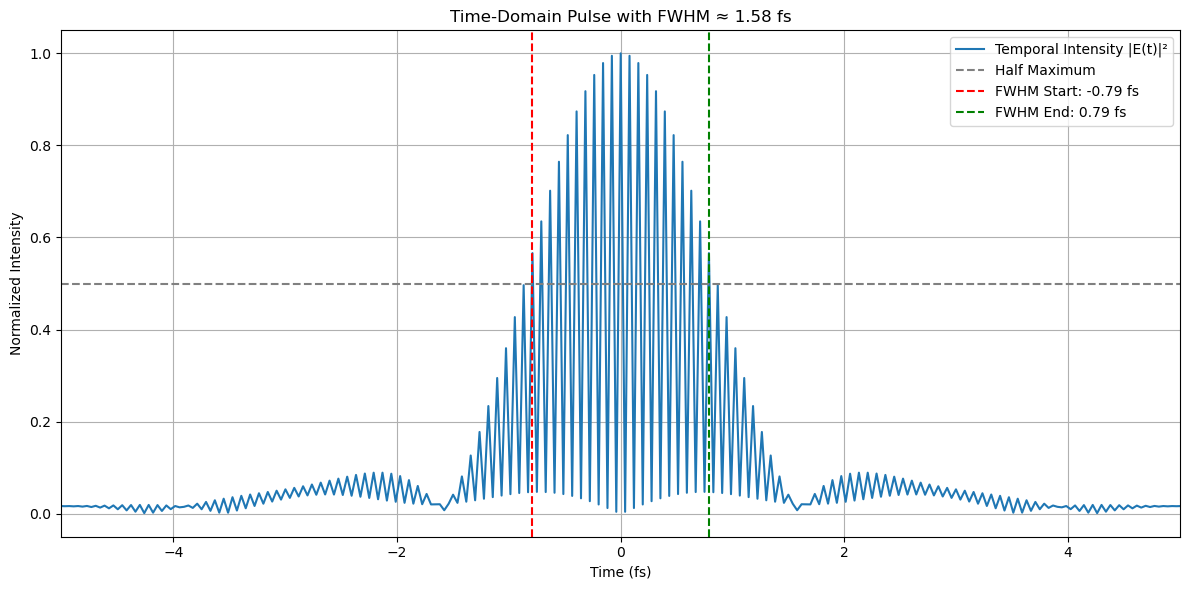

In [ ]:
# ---------------------------
# 6. Calculate FWHM
# ---------------------------

def compute_fwhm(t, intensity):
    intensity = intensity / np.max(intensity)
    half_max = 0.5
    indices = np.where(intensity >= half_max)[0]

    if len(indices) < 2:
        return None  # FWHM not well-defined

    t1 = t[indices[0]]
    t2 = t[indices[-1]]
    return t1, t2


# ---------------------------
# 7. Plot Temporal Profile, with FWHM
# ---------------------------

t1, t2 = compute_fwhm(t_fs, I_t)
fwhm = t2-t1

plt.figure(figsize=(12, 6))
plt.plot(t_fs, I_t, label='Temporal Intensity |E(t)|²')
plt.axhline(0.5, color='gray', linestyle='--', label='Half Maximum')
plt.axvline(t1, color='red', linestyle='--', label=f'FWHM Start: {t1:.2f} fs')
plt.axvline(t2, color='green', linestyle='--', label=f'FWHM End: {t2:.2f} fs')
plt.title(f'Time-Domain Pulse with FWHM ≈ {fwhm:.2f} fs')
plt.xlabel('Time (fs)')
plt.ylabel('Normalized Intensity')
plt.xlim(-5, 5)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
